In [ ]:
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [ ]:
#Parameters for Study

# Reaction Conditions
P = 20
Tmin = 800
Tmax = 1200

ratio =1.2
# Reactor Feed Specifications
nFeedin = dict()
nFeedin['CH4'] = 1
nFeedin['H2O'] = ratio *nFeedin['CH4']
nFeedin['CO'] = 0
nFeedin['H2'] = 0

# List of Components
C = nFeedin.keys()

In [ ]:
# Enthalpy and Free Energy of Formation
Gf = dict()
Hf = dict()

Gf['CO'] = -137270
Hf['CO'] = -110530

Gf['H2'] = 0
Hf['H2'] = 0

Gf['CH4'] = -50490
Hf['CH4'] = -74520

Gf['H2O'] = -228590
Hf['H2O'] = -241830

In [ ]:
# Reaction Stoichiometry
nu = dict()
nu['CO']  = +1
nu['H2']  = +3
nu['CH4'] = -1
nu['H2O'] = -1

Hr = sum([nu[c]*Hf[c] for c in C])
print("Hr = {:7.3f} kJ/gmol".format(Hr/1000))

Gr = sum([nu[c]*Gf[c] for c in C])
print("Gr = {:7.3f} kJ/gmol".format(Gr/1000))

Hr = 205.820 kJ/gmol
Gr = 141.810 kJ/gmol


In [ ]:
R = 8.314 # J/K/gmol
def lnKr(T):
    return -((Gr-Hr)/298 + Hr/T)/R # Vant Hoff Equation


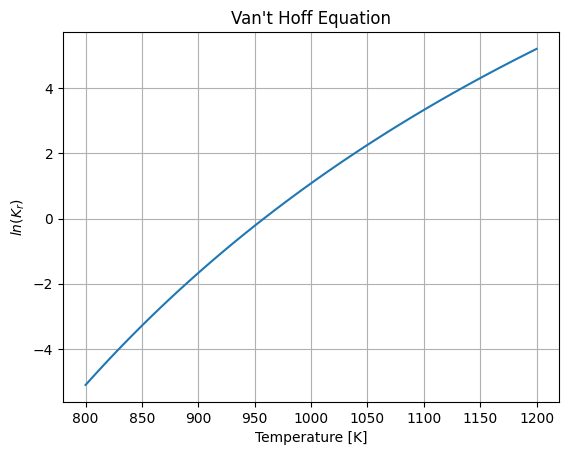

In [ ]:
T = np.linspace(Tmin,Tmax,100)
plt.plot(T,[lnKr(T) for T in T])
plt.xlabel('Temperature [K]')
plt.ylabel('$ln(K_{r})$')
plt.title('Van\'t Hoff Equation')
plt.grid()

In [ ]:
nOut = dict()
for c in C:
    nOut[c] = lambda x,c=c: nFeedin[c] + nu[c]*x

Maximum molar extent of reaction = 1.00


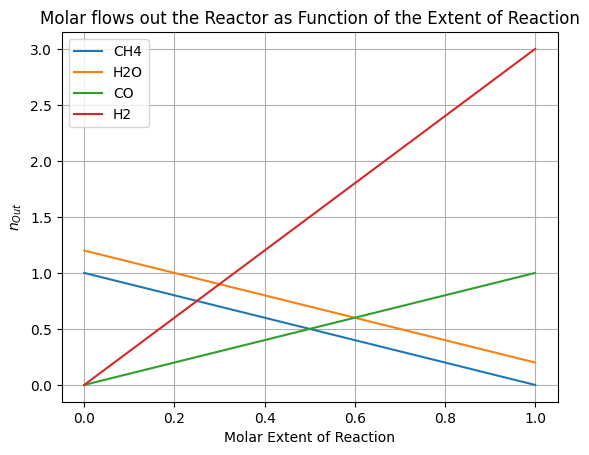

In [ ]:
xMax = np.inf
for c in C:
    if nu[c] < 0:
        xMax = min(xMax,-nFeedin[c]/nu[c])

print('Maximum molar extent of reaction = {:.2f}'.format(xMax))

x = np.linspace(0,xMax)

for c in C:
    plt.plot(x,[nOut[c](x) for x in x])
plt.legend(C)
plt.xlabel('Molar Extent of Reaction')
plt.ylabel('$n_{Out}$')
plt.title('Molar flows out the Reactor as Function of the Extent of Reaction')
plt.grid()

In [ ]:
def nTotal(x):
    nTotal = 0
    for c in C:
        nTotal += nOut[c](x)
    return nTotal

In [ ]:
y = dict()
for c in C:
    y[c] = lambda x,c=c: nOut[c](x)/nTotal(x)

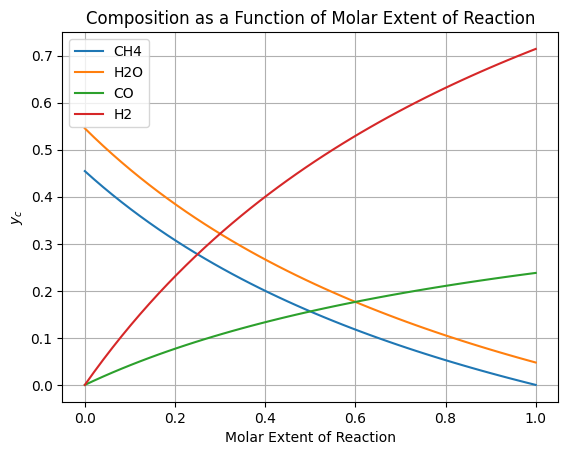

In [ ]:
x = np.linspace(0,1)
for c in C:
    plt.plot(x,[y[c](x) for x in x])
plt.legend(C)
plt.xlabel('Molar Extent of Reaction')
plt.ylabel('$y_c$')
plt.title('Composition as a Function of Molar Extent of Reaction')
plt.grid()

In [ ]:
def lnKa(x):
    lnKa = 0;
    epsilon = 1e-12 # Small epsilon to prevent log(0) errors
    for c in C:
        arg_for_log = P*y[c](x)
        lnKa += nu[c]*np.log(max(arg_for_log, epsilon))
    return lnKa

<>:4: SyntaxWarning: invalid escape sequence '\l'
<>:4: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_4874/761228878.py:4: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('$\ln(Ka)$')
/tmp/ipykernel_4874/4199234577.py:4: RuntimeWarning: divide by zero encountered in log
  lnKa += nu[c]*np.log(P*y[c](x))


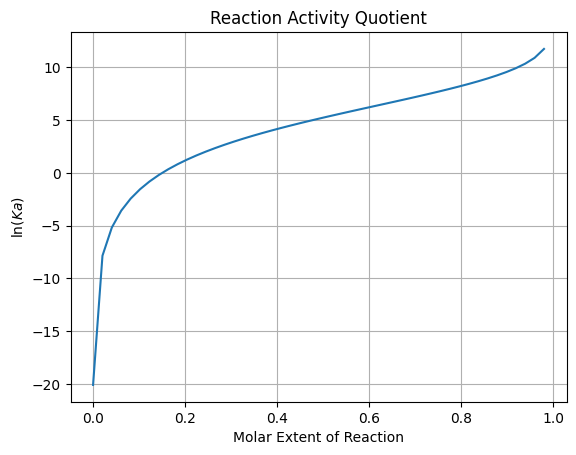

In [ ]:
x = np.linspace(0.001,1)
plt.plot(x,[lnKa(x) for x in x])
plt.xlabel('Molar Extent of Reaction')
plt.ylabel('$\ln(Ka)$')
plt.title('Reaction Activity Quotient');
plt.grid()

<>:6: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_4874/3672702556.py:6: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('$\ln(Kr)$')
/tmp/ipykernel_4874/4199234577.py:4: RuntimeWarning: divide by zero encountered in log
  lnKa += nu[c]*np.log(P*y[c](x))


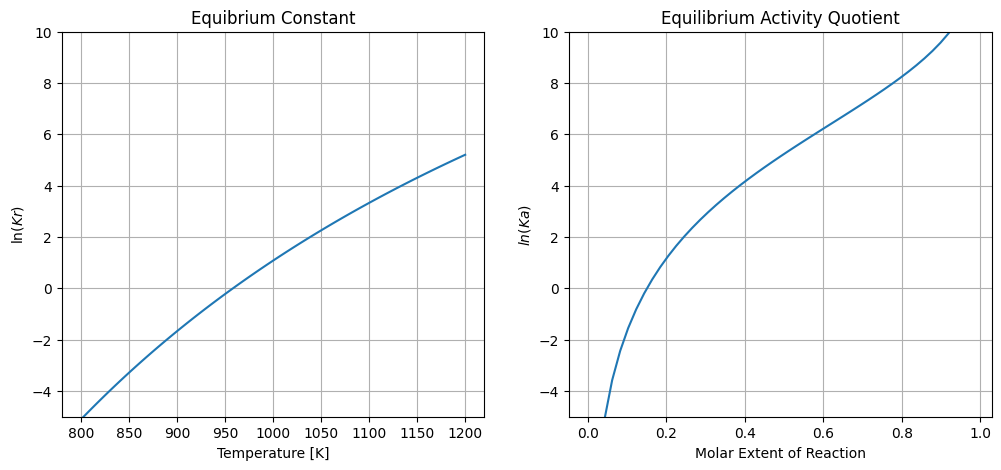

In [ ]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(T,[lnKr(T) for T in T])
plt.ylim(-5,10)
plt.xlabel('Temperature [K]')
plt.ylabel('$\ln(Kr)$')
plt.title('Equibrium Constant')
plt.grid()

plt.subplot(1,2,2)
plt.plot(x,[lnKa(x) for x in x])
plt.ylim(-5,10)
plt.xlabel('Molar Extent of Reaction')
plt.ylabel('$ln(Ka)$')
plt.title('Equilibrium Activity Quotient')
plt.grid()

<>:7: SyntaxWarning: invalid escape sequence '\l'
<>:9: SyntaxWarning: invalid escape sequence '\l'
<>:16: SyntaxWarning: invalid escape sequence '\l'
<>:7: SyntaxWarning: invalid escape sequence '\l'
<>:9: SyntaxWarning: invalid escape sequence '\l'
<>:16: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_4874/1483816831.py:7: SyntaxWarning: invalid escape sequence '\l'
  ax1.plot(T, [lnKr(t_val) for t_val in T], 'b-', label='$\ln(K_r)$')
/tmp/ipykernel_4874/1483816831.py:9: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_ylabel('$\ln(K_r)$', color='b')
/tmp/ipykernel_4874/1483816831.py:16: SyntaxWarning: invalid escape sequence '\l'
  ax2.plot(x, [lnKa(x_val) for x_val in x], 'r-', label='$\ln(K_a)$')
/tmp/ipykernel_4874/4199234577.py:4: RuntimeWarning: divide by zero encountered in log
  lnKa += nu[c]*np.log(P*y[c](x))


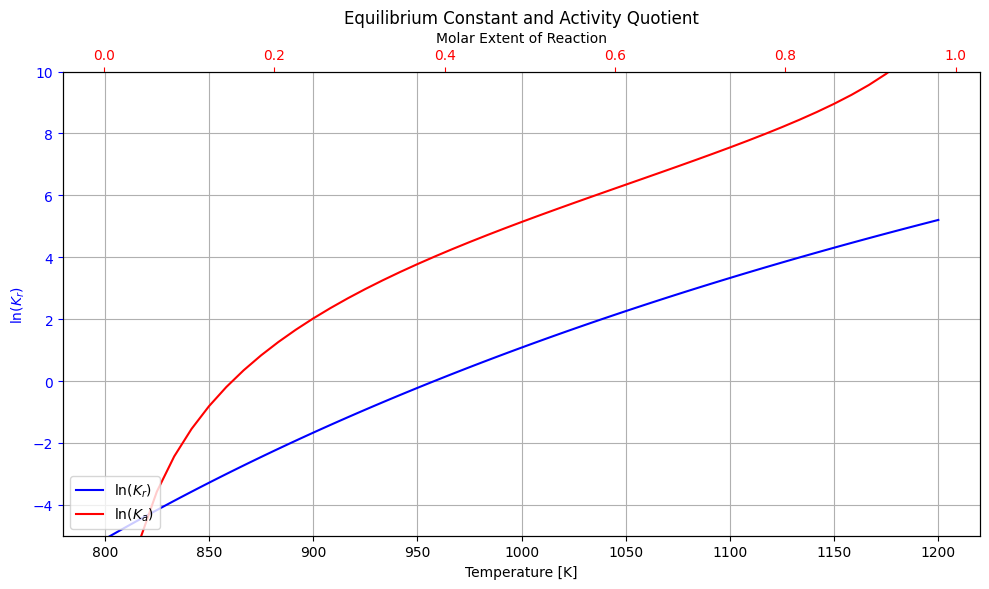

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot lnKr(T) on the primary axis (bottom x-axis)
ax1.plot(T, [lnKr(t_val) for t_val in T], 'b-', label='$\ln(K_r)$')
ax1.set_xlabel('Temperature [K]')
ax1.set_ylabel('$\ln(K_r)$', color='b')
ax1.tick_params('y', colors='b')
ax1.set_ylim(-5, 10)
ax1.grid(True)

# Create a twin x-axis for lnKa(x) (top x-axis)
ax2 = ax1.twiny()
ax2.plot(x, [lnKa(x_val) for x_val in x], 'r-', label='$\ln(K_a)$')
ax2.set_xlabel('Molar Extent of Reaction')
ax2.tick_params('x', colors='r')
ax2.set_ylim(-5, 10)

# Set the title and add a legend
plt.title('Equilibrium Constant and Activity Quotient')

# Combine legends from both axes
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='lower left')

plt.tight_layout()
plt.show()

In [ ]:
from scipy.optimize import brentq as fzero

xEquil = lambda T: fzero(lambda x: lnKa(x) - lnKr(T), 0, xMax)

/tmp/ipykernel_4874/4199234577.py:4: RuntimeWarning: divide by zero encountered in log
  lnKa += nu[c]*np.log(P*y[c](x))


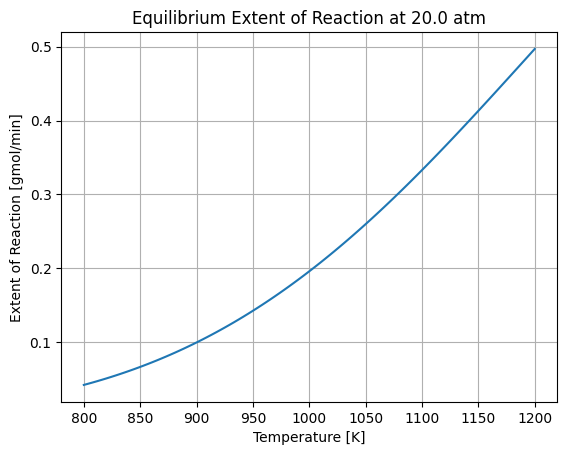

In [ ]:
plt.plot(T,[xEquil(T) for T in T])
plt.xlabel('Temperature [K]')
plt.ylabel('Extent of Reaction [gmol/min]')
plt.title('Equilibrium Extent of Reaction at {:.1f} atm'.format(P))
plt.grid()

/tmp/ipykernel_4874/4199234577.py:4: RuntimeWarning: divide by zero encountered in log
  lnKa += nu[c]*np.log(P*y[c](x))


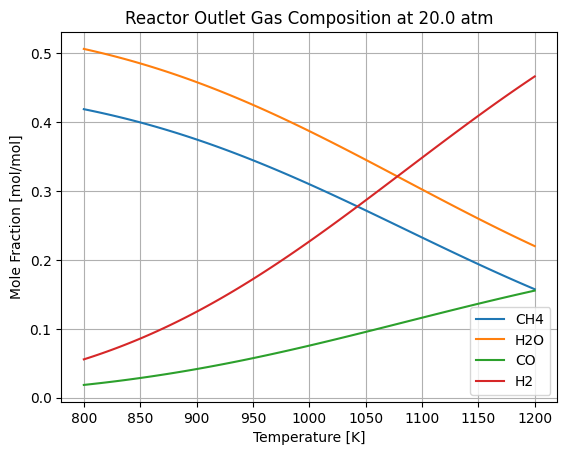

In [ ]:
yEquil = dict()
for c in C:
    yEquil[c] = lambda T,c=c: y[c](xEquil(T))

for c in C:
    plt.plot(T,[yEquil[c](T) for T in T])

plt.legend(C)
plt.xlabel('Temperature [K]')
plt.ylabel('Mole Fraction [mol/mol]')
plt.title('Reactor Outlet Gas Composition at {:.1f} atm'.format(P))
plt.grid()


/tmp/ipykernel_4874/4199234577.py:4: RuntimeWarning: divide by zero encountered in log
  lnKa += nu[c]*np.log(P*y[c](x))


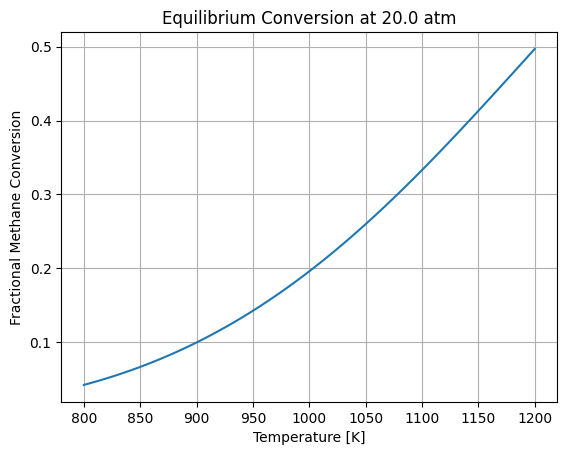

In [ ]:
fconv = lambda T: (nFeedin['CH4'] - nOut['CH4'](xEquil(T)))/nFeedin['CH4']

plt.plot(T,[fconv(T) for T in T])
plt.xlabel('Temperature [K]')
plt.ylabel('Fractional Methane Conversion')
plt.title('Equilibrium Conversion at {:.1f} atm'.format(P))
plt.grid()

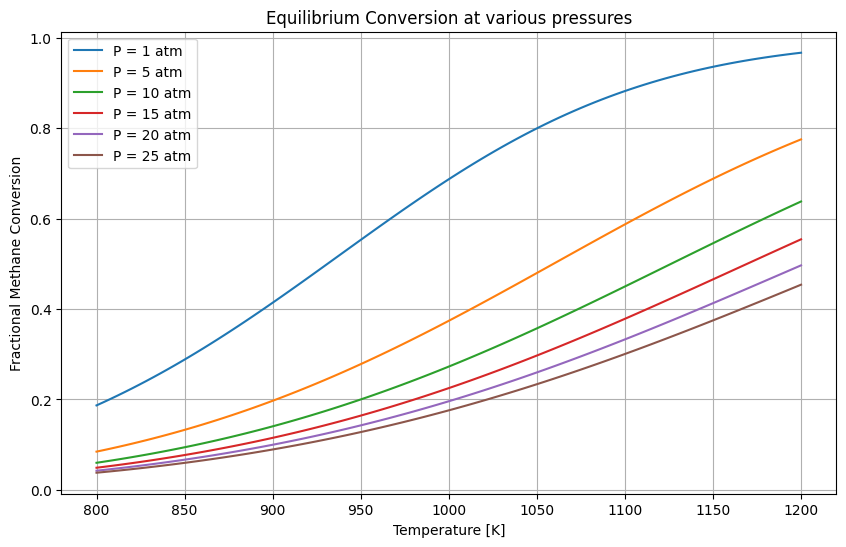

In [ ]:
P_values = [1, 5, 10, 15, 20, 25]

plt.figure(figsize=(10, 6))

for current_P in P_values:

    # Redefine lnKa to use the current_P dynamically
    def lnKa_local(x, P_val=current_P):
        lnKa_val = 0
        # Use a small epsilon to prevent np.log from encountering zero, which causes RuntimeWarning
        epsilon = 1e-12
        for c in C:
            arg_for_log = P_val * y[c](x)
            # Ensure the argument to np.log is always positive and at least epsilon
            lnKa_val += nu[c] * np.log(max(arg_for_log, epsilon))
        return lnKa_val

    # Redefine xEquil to use the local lnKa_local.
    # Use a lower bound of 0.001 (from previous cell's context) and an upper bound slightly less than xMax.
    # This helps avoid evaluating lnKa at x=xMax where reactant mole fractions might be exactly zero.
    xEquil_local = lambda T, P_val=current_P: fzero(lambda x_val: lnKa_local(x_val, P_val) - lnKr(T), 0.001, xMax - 1e-6)

    fconv = lambda T: (nFeedin['CH4'] - nOut['CH4'](xEquil_local(T, current_P)))/nFeedin['CH4']

    plt.plot(T,[fconv(T) for T in T], label=f'P = {current_P} atm')

plt.xlabel('Temperature [K]')
plt.ylabel('Fractional Methane Conversion')
plt.title('Equilibrium Conversion at various pressures')
plt.legend()
plt.grid()

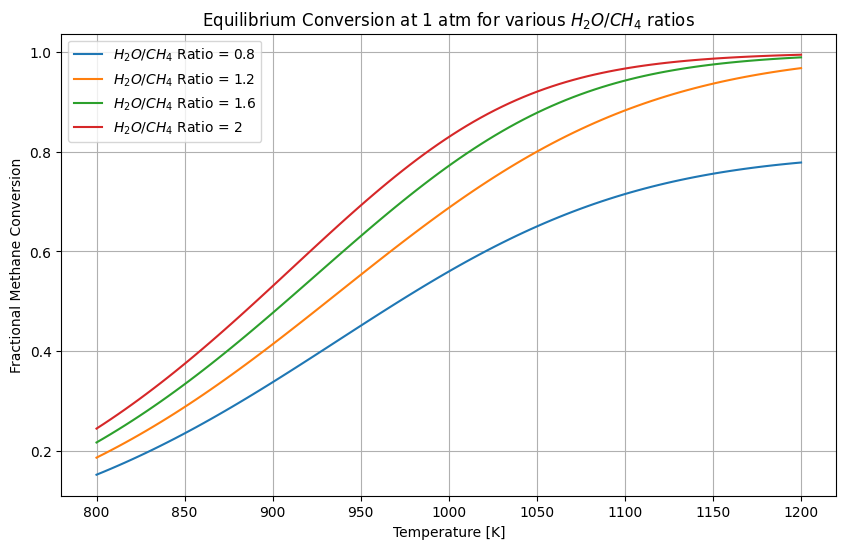

In [ ]:
# Set the pressure for this specific plot to 1 atm as requested by the user
P_for_this_plot = 1 # atm

# Define the array of H2O/CH4 ratios to consider
ratio_values = [0.8,1.2,1.6, 2]

plt.figure(figsize=(10, 6))

# Store the original nFeedin['H2O'] value to restore it later
original_nFeedin_H2O = nFeedin['H2O']

for current_ratio in ratio_values:
    # 1. Update nFeedin['H2O'] based on the current ratio
    nFeedin['H2O'] = current_ratio * nFeedin['CH4']

    # 2. Recalculate xMax as it depends on the updated nFeedin
    current_xMax = np.inf
    for c_item in C:
        if nu[c_item] < 0:
            current_xMax = min(current_xMax, -nFeedin[c_item] / nu[c_item])

    # 3. Redefine nOut functions, ensuring they capture the current nFeedin value from this iteration
    local_nOut = dict()
    for c_item in C:
        local_nOut[c_item] = lambda x_val, c=c_item, nF=nFeedin: nF[c] + nu[c] * x_val

    # 4. Redefine nTotal function, which uses the local_nOut functions
    def local_nTotal(x_val):
        total = 0
        for c_item in C:
            total += local_nOut[c_item](x_val)
        return total

    # 5. Redefine y (mole fraction) functions, which use local_nOut and local_nTotal
    local_y = dict()
    for c_item in C:
        local_y[c_item] = lambda x_val, c=c_item, lnO=local_nOut, lnT=local_nTotal: lnO[c](x_val) / lnT(x_val)

    # 6. Redefine lnKa_local using the fixed pressure for this plot and the current local_y functions
    def lnKa_local(x_val, P_val=P_for_this_plot):
        lnKa_val = 0
        epsilon = 1e-12 # Small epsilon to prevent log(0) errors
        for c_item in C:
            arg_for_log = P_val * local_y[c_item](x_val)
            lnKa_val += nu[c_item] * np.log(max(arg_for_log, epsilon))
        return lnKa_val

    # 7. Redefine xEquil_local using lnKa_local and the current_xMax
    # The lower bound for fzero is set to a small positive value (0.001) to avoid issues at x=0
    # The upper bound is slightly less than current_xMax to avoid issues where mole fractions might become zero
    xEquil_local = lambda T_val: fzero(lambda x_val: lnKa_local(x_val) - lnKr(T_val), 0.001, current_xMax - 1e-6)

    # 8. Calculate fractional conversion for the current ratio and plot it
    fconv = lambda T_val: (nFeedin['CH4'] - local_nOut['CH4'](xEquil_local(T_val))) / nFeedin['CH4']

    plt.plot(T, [fconv(T_val) for T_val in T], label=f'$H_2O/CH_4$ Ratio = {current_ratio}')

plt.xlabel('Temperature [K]')
plt.ylabel('Fractional Methane Conversion')
plt.title(f'Equilibrium Conversion at {P_for_this_plot} atm for various $H_2O/CH_4$ ratios')
plt.legend()
plt.grid()

# Restore the original nFeedin['H2O'] value
nFeedin['H2O'] = original_nFeedin_H2O

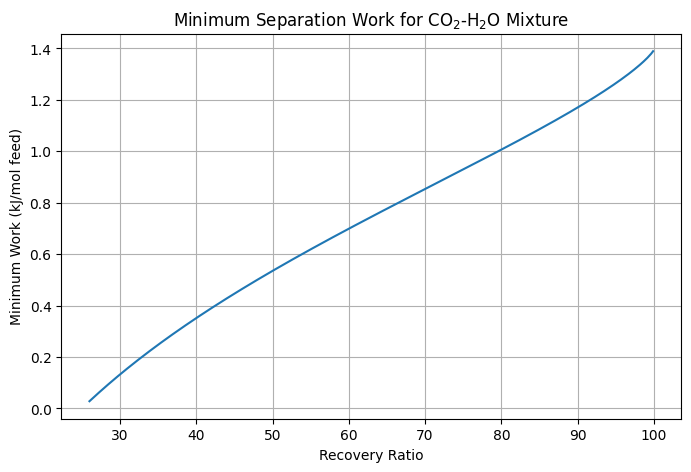

Minimum work at 75% purity = 0.9293 kJ/mol feed


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

R = 8.314      # J/mol-K
T = 298.15     # K

# Feed composition
z_co2 = 0.25
z_h2o = 0.75

purities = np.linspace(0.26, 0.999, 300)

Wmin = []

# Feed entropy term
feed_term = (
    z_co2*np.log(z_co2)
    + z_h2o*np.log(z_h2o)
)

for y in purities:

    # Product flowrate for 100% CO2 recovery
    np_prod = z_co2 / y

    # Product entropy term
    product_term = (
        y*np.log(y)
        + (1-y)*np.log(1-y)
    )

    # Minimum reversible work
    w = R*T*(np_prod*product_term - feed_term)

    Wmin.append(w)

Wmin = np.array(Wmin)

# Plot
plt.figure(figsize=(8,5))
plt.plot(purities*100, Wmin/1000)

plt.xlabel("Recovery Ratio")
plt.ylabel("Minimum Work (kJ/mol feed)")
plt.title("Minimum Separation Work for CO$_2$-H$_2$O Mixture")
plt.grid(True)

plt.show()

# Example value at 75%
y = 0.75
np_prod = z_co2 / y
product_term = y*np.log(y)+(1-y)*np.log(1-y)

W75 = R*T*(np_prod*product_term - feed_term)

print(f"Minimum work at 75% purity = {W75/1000:.4f} kJ/mol feed")

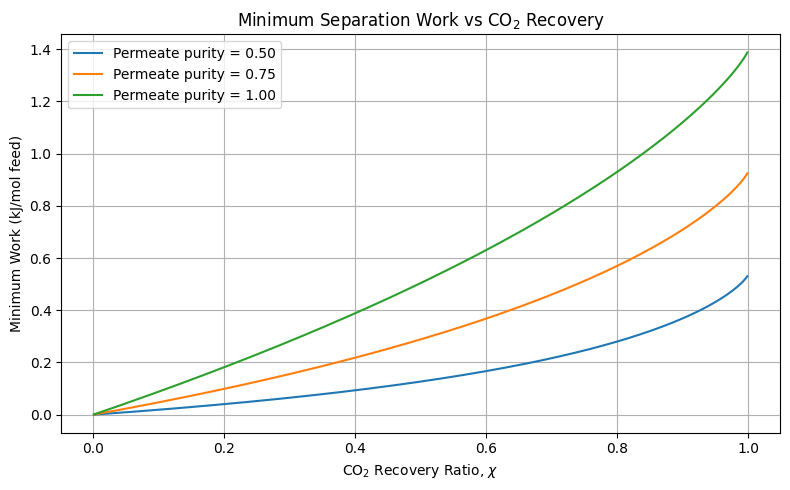

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

R = 8.314      # J/mol-K
T = 298.15     # K

# Feed composition
z = 0.25       # CO2 mole fraction in feed

feed_term = z*np.log(z) + (1-z)*np.log(1-z)

purities = [0.5, 0.75, 0.9999]   # use 0.9999 instead of 1 to avoid log(0)

plt.figure(figsize=(8,5))

for y in purities:

    # Maximum possible recovery
    chi_max = min(0.999, y/z)

    chi_vals = np.linspace(0.001, chi_max, 300)

    Wmin = []

    for chi in chi_vals:

        theta = chi*z/y

        x = z*(1-chi)/(1-theta)

        # Numerical protection
        x = np.clip(x, 1e-12, 1-1e-12)

        perm_term = y*np.log(y) + (1-y)*np.log(1-y)
        ret_term = x*np.log(x) + (1-x)*np.log(1-x)

        W_RT = (
            theta*perm_term
            + (1-theta)*ret_term
            - feed_term
        )

        Wmin.append(W_RT*R*T/1000)  # kJ/mol feed

    label = f"Permeate purity = {y:.2f}"
    plt.plot(chi_vals, Wmin, label=label)

plt.xlabel("CO$_2$ Recovery Ratio, $\\chi$")
plt.ylabel("Minimum Work (kJ/mol feed)")
plt.title("Minimum Separation Work vs CO$_2$ Recovery")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()